# 06 — Ground Truth Validation
Compare the YOLO-derived heatmap against a heatmap built from the annotated GT head positions.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io
import seaborn as sns

sys.path.insert(0, '..')
from src.heatmap import FLOOR_W, FLOOR_H, SIGMA, make_floor_canvas, project_points, build_heatmap

sns.set_theme(style='whitegrid')

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')

H = np.load(PROCESSED / 'homography.npy')

## Extract GT head positions across all frames

In [2]:
gt = scipy.io.loadmat(RAW / 'mall_gt.mat')

rows = []
for i in range(gt['frame'].shape[1]):
    heads = gt['frame'][0, i][0, 0][0]  # (N, 2) float — (x, y) head positions
    for x, y in heads:
        rows.append({'frame_id': i + 1, 'x': x, 'y': y})

gt_df = pd.DataFrame(rows)
print(f'Total GT head positions: {len(gt_df)} across {gt_df["frame_id"].nunique()} frames')
print(gt_df.head())

Total GT head positions: 62315 across 2000 frames
   frame_id           x          y
0         1  126.779863  60.704778
1         1  116.950512  47.598976
2         1  175.107509  44.322526
3         1  184.117747  45.141638
4         1  192.308874  44.322526


## Project GT positions to floor plan

GT annotations mark the **head** of each person. The homography was calibrated
using **foot** positions (bottom of bounding box), so there will be a systematic
vertical offset — heads project further from the camera than feet for the same person.

In [3]:
pts = gt_df[['x', 'y']].values
proj = project_points(pts, H)

gt_df['px'] = proj[:, 0]
gt_df['py'] = proj[:, 1]

in_bounds = gt_df['px'].between(0, FLOOR_W) & gt_df['py'].between(0, FLOOR_H)
gt_proj = gt_df[in_bounds].copy()

print(f'In-bounds: {len(gt_proj)} / {len(gt_df)} ({in_bounds.mean()*100:.1f}%)')

In-bounds: 54884 / 62315 (88.1%)


## Build GT and YOLO heatmaps

In [4]:
yolo_proj = pd.read_csv(PROCESSED / 'projected_detections.csv')

heatmap_gt   = build_heatmap(gt_proj)
heatmap_yolo = build_heatmap(yolo_proj)

print(f'GT   heatmap shape: {heatmap_gt.shape}')
print(f'YOLO heatmap shape: {heatmap_yolo.shape}')

GT   heatmap shape: (1200, 820)
YOLO heatmap shape: (1200, 820)


## Side-by-side comparison

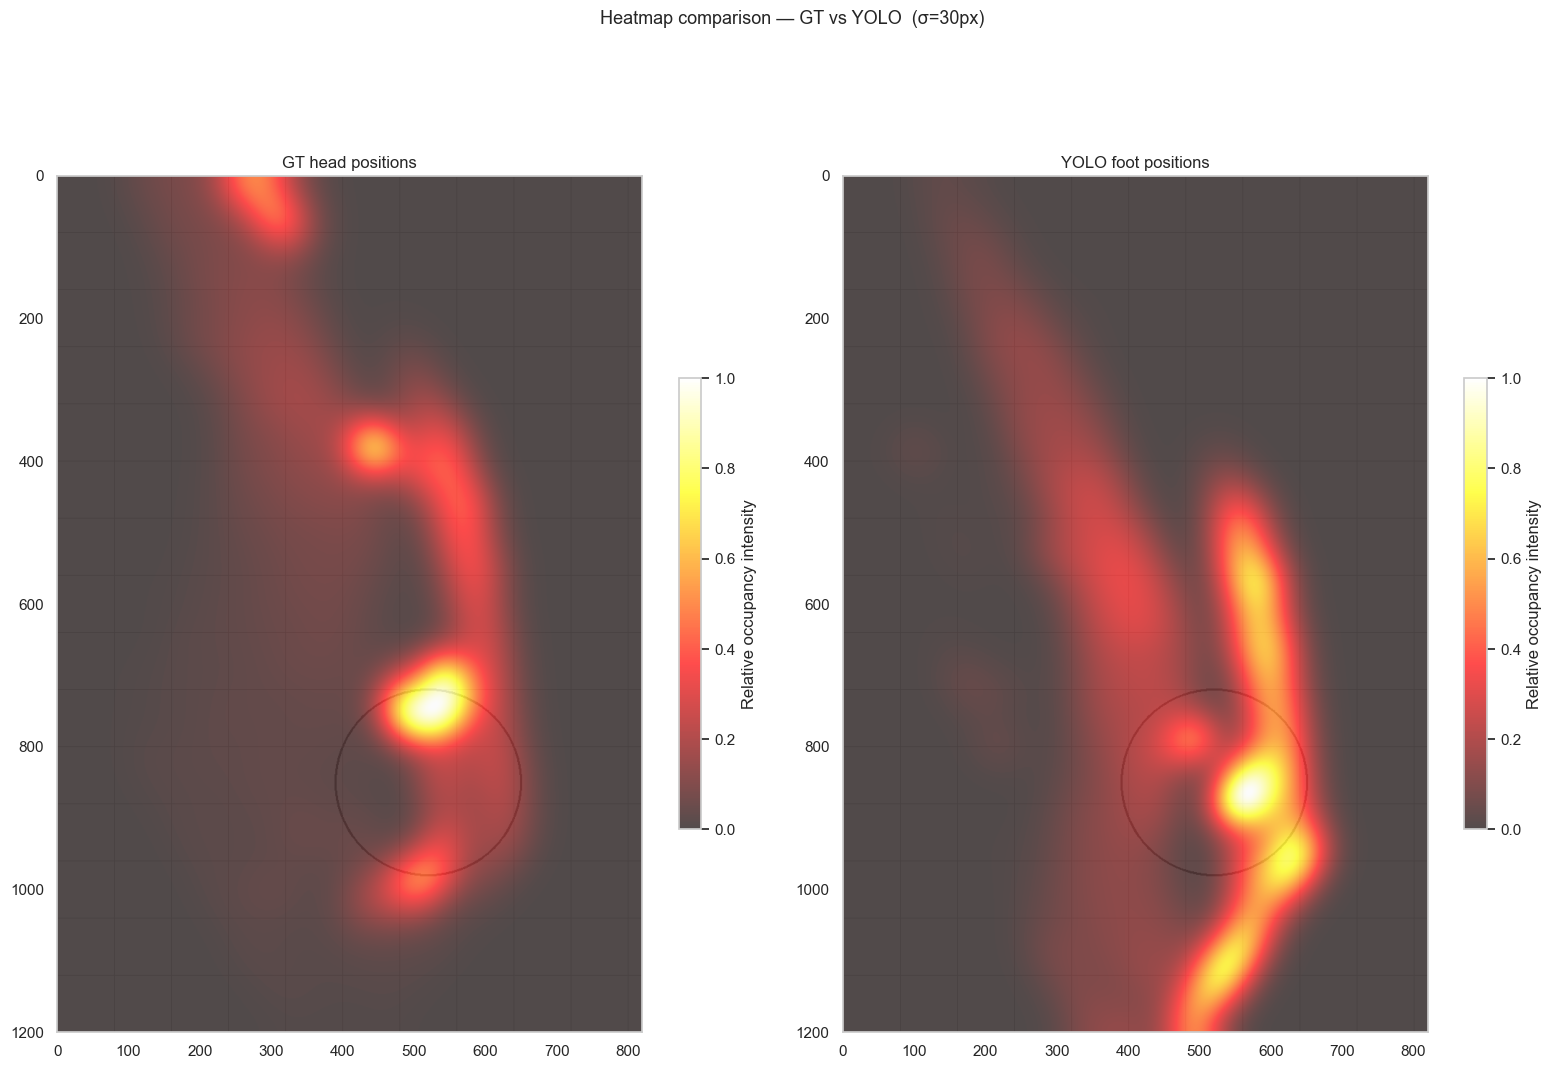

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 12))

titles = ['GT head positions', f'YOLO foot positions']
heatmaps = [heatmap_gt, heatmap_yolo]

for ax, hm, title in zip(axes, heatmaps, titles):
    ax.imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
    im = ax.imshow(hm, extent=[0, FLOOR_W, FLOOR_H, 0],
                   cmap='hot', alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Relative occupancy intensity', shrink=0.4)
    ax.grid(False)
    ax.set_title(title, fontsize=12)

plt.suptitle(f'Heatmap comparison — GT vs YOLO  (σ={SIGMA}px)', fontsize=13)
plt.tight_layout()
plt.show()

## Pixel-level difference map

Signed difference `YOLO − GT`. Positive (warm) = YOLO detects more;
negative (cool) = YOLO misses relative to GT.

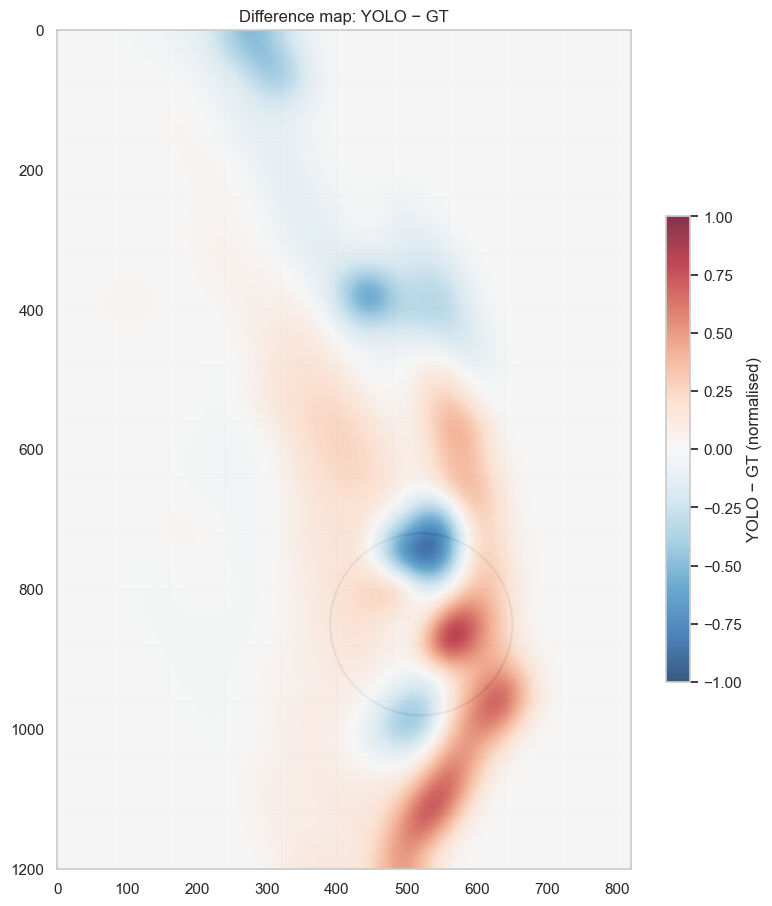

Mean absolute difference: 0.0705
Max over-detection:  0.8025   Max under-detection: -0.8742


In [6]:
diff = heatmap_yolo - heatmap_gt

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
im = ax.imshow(diff, extent=[0, FLOOR_W, FLOOR_H, 0],
               cmap='RdBu_r', alpha=0.8,
               vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='YOLO − GT (normalised)', shrink=0.4)
ax.grid(False)
ax.set_title('Difference map: YOLO − GT', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Mean absolute difference: {np.abs(diff).mean():.4f}')
print(f'Max over-detection:  {diff.max():.4f}   Max under-detection: {diff.min():.4f}')